## Stage 0: User Inputs and Setup

In this stage we:

1. **Define User Inputs:**
   - Target (nominal center) frequencies (in Hz)
   - An initial search bandwidth (±Δf) to cover possible frequency drift.
2. **Configure the SDR:**
   - Set the sample rate, center frequency, bit depth, etc.
3. **Set Calibration Parameters:**
   - Initialize placeholders for noise floor estimation and gain calibration.
4. **Initialize Data Structures:**
   - A circular buffer for IQ samples.
   - Bayesian trackers (one per target frequency) to track frequency drift with initial uncertainty.
   - An event output queue to store frequency detection events.

In [1]:
import numpy as np
from collections import deque
import queue
import glob
import os
import struct
import matplotlib.pyplot as plt
from scipy.signal import get_window

### User-Defined Frequencies and Initial Search Bandwidth 

In [2]:
target_freqs = [
    173_964_000,
    173_043_000,
]

# Define an initial search bandwidth ±Δf (in Hz) for each target frequency
delta_f = 10_000  # ±10 kHz around each target frequency

### SDR Configuration

In [3]:
# SDR parameters:
block_length = 2048  # Number of samples per block
sample_rate = 1_500_000  # Sampling rate in Hz
center_frequency = 173_500_000  # Center frequency in Hz
bit_depth = 16  # Bit depth of the IQ samples

### Calibration Parameters

In [4]:
noise_floor_estimate = None  # To be computed from "silent" segments of IQ data
gain_calibration_factor = 1.0  # Default gain factor (can be updated later)

### Initialize Data Structures

**Circular Buffer for IQ Samples**

In [5]:
class CircularBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def append(self, data):
        self.buffer.append(data)

    def get_all(self):
        return np.array(self.buffer)

    def clear(self):
        self.buffer.clear()


# Create an instance of the circular buffer
iq_buffer_size = 10_000  # Adjust as needed (number of samples)
iq_circular_buffer = CircularBuffer(max_size=iq_buffer_size)

**Bayesian Tracker Class**

In [6]:
class BayesianTracker:
    def __init__(self, initial_frequency, initial_uncertainty):
        # Initialize with the nominal frequency and an uncertainty (in Hz)
        self.frequency = initial_frequency
        self.uncertainty = initial_uncertainty

    def update(self, new_measurement):
        # A simple update rule (placeholder for a proper Kalman filter)
        # Here we blend the new measurement with the previous estimate
        alpha = 0.5  # blending factor (tunable)
        self.frequency = alpha * new_measurement + (1 - alpha) * self.frequency
        # Optionally, update uncertainty (e.g., reduce if measurement is consistent)
        self.uncertainty *= 0.9
        return self.frequency

    def no_detection_update(self):
        # When no measurement is detected, increase uncertainty
        self.uncertainty *= 1.1


# Create a Bayesian tracker for each target frequency
initial_uncertainty = 100  # Example initial uncertainty in Hz
bayesian_trackers = {
    freq: BayesianTracker(freq, initial_uncertainty) for freq in target_freqs
}

**Event Output Queue**


In [7]:
# This queue will store detection events (e.g., dictionaries with frequency, gain, timestamp, confidence)
event_output_queue = queue.Queue()

In [8]:
# --- Print Initialization Information ---
print("Stage 0: Initialization Complete")
print(f"Target frequencies (MHz): {[f/1e6 for f in target_freqs]}")
print(f"Initial search bandwidth: ±{delta_f} Hz")
print(
    f"SDR Configuration: Sample rate = {sample_rate} Hz, Center frequency = {center_frequency} Hz, Bit depth = {bit_depth}"
)
print(f"Bayesian Tracker initial uncertainty: {initial_uncertainty} Hz")
print(f"Circular Buffer size: {iq_buffer_size} samples")
print("Event output queue initialized.")

Stage 0: Initialization Complete
Target frequencies (MHz): [173.964, 173.043]
Initial search bandwidth: ±10000 Hz
SDR Configuration: Sample rate = 1500000 Hz, Center frequency = 173500000 Hz, Bit depth = 16
Bayesian Tracker initial uncertainty: 100 Hz
Circular Buffer size: 10000 samples
Event output queue initialized.


## Stage 1: Data Acquisition and Preprocessing

In this stage, we:

1. **Load Raw IQ Data:**  
   - Read the raw binary IQ data from our SDR raw files.
   - Convert the raw data (assumed 24-bit, with two 16-bit signed integers per sample) into complex IQ samples.

2. **Simulate Streaming & Block Processing:**  
   - Split the IQ samples into blocks (using a block length equal to our FFT length) to simulate real-time streaming.

3. **Adaptive Calibration:**  
   - For each block, estimate the noise floor (using, for example, the median of the block's magnitude) and use this to normalize the block.

4. **Store in Data Structures:**  
   - Append the calibrated blocks into a circular buffer for downstream processing.

We'll also plot the noise floor estimates across blocks for visualization.

### Load Raw IQ Data

In [9]:
data_dir = "data"
raw_files = sorted(glob.glob(os.path.join(data_dir, "RAW_DATA_*")))
if len(raw_files) == 0:
    raise FileNotFoundError("No raw data files found in the data directory!")
    
raw_file = raw_files[0]
print(f"Loading raw data from: {raw_file}")

with open(raw_file, "rb") as data_file:
    data = data_file.read()

# Convert raw data to complex IQ samples.
scale_factor = 2**bit_depth
samples = []
num_samples = int(len(data) / 4)  # each sample is 4 bytes (2 shorts)
for i in range(num_samples):
    # Each sample is two 16-bit signed integers: one for I and one for Q.
    tsample = struct.unpack("hh", data[i * 4 : (i + 1) * 4])
    sample = (tsample[0] + 1j * tsample[1]) / scale_factor
    samples.append(sample)
    
seq_samples = np.array(samples)
print(f"Loaded {len(seq_samples)} IQ samples.")

Loading raw data from: data\RAW_DATA_000039_000001
Loaded 16779264 IQ samples.


### Simulate Streaming: Split IQ Data into Blocks


In [10]:
def block_generator(samples, block_length):
    """Generator that yields blocks of IQ samples from the full sequence."""
    num_blocks = len(samples) // block_length
    for i in range(num_blocks):
        yield samples[i * block_length : (i + 1) * block_length]

### Adaptive Calibration

In [11]:
def adaptive_calibration(IQ_block):
    """
    Perform adaptive calibration on a block of IQ samples.
    Here, we estimate the noise floor as the median of the absolute values
    and then normalize the block by this value.

    Returns:
        calibrated_block: The normalized IQ block.
        noise_est: The estimated noise floor (median magnitude).
    """
    noise_est = np.median(np.abs(IQ_block))
    if noise_est > 0:
        calibrated_block = IQ_block / noise_est
    else:
        calibrated_block = IQ_block
    return calibrated_block, noise_est


# Process blocks: for each block, perform calibration and append to circular buffer.
noise_floors = []  # to store noise estimates for visualization
processed_blocks = []  # also store calibrated blocks for later use (or visualization)

for block in block_generator(seq_samples, block_length):
    calibrated_block, noise_est = adaptive_calibration(block)
    noise_floors.append(noise_est)
    processed_blocks.append(calibrated_block)
    iq_circular_buffer.append(calibrated_block)

print(f"Processed {len(processed_blocks)} blocks of {block_length} samples each.")

Processed 8193 blocks of 2048 samples each.


### Visualization of Noise Floor Estimates

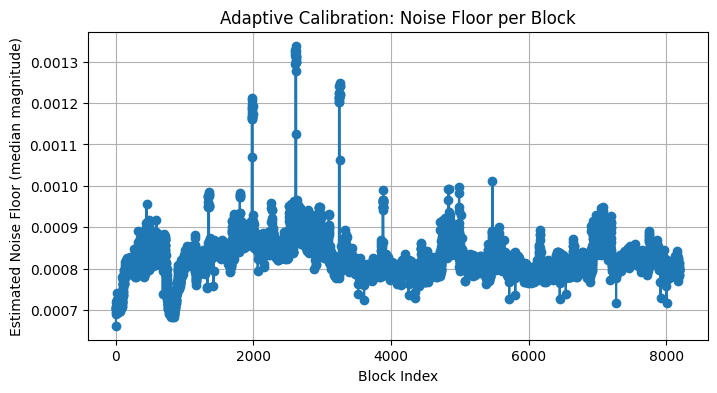

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(noise_floors, marker='o', linestyle='-')
plt.xlabel("Block Index")
plt.ylabel("Estimated Noise Floor (median magnitude)")
plt.title("Adaptive Calibration: Noise Floor per Block")
plt.grid(True)
plt.show()

### Stage 2: Coarse STFT and Candidate Frequency Region Identification

In this stage we:

1. Concatenate all calibrated IQ blocks to form a continuous signal.
2. Compute a coarse Short-Time Fourier Transform (STFT) on the calibrated IQ data.
   - We use a Hann window and set an overlap factor (here 75% overlap).
3. Create an absolute frequency axis by adding the SDR’s center frequency.
4. For each user-specified target frequency, we extract the frequency bins within the search band [f_target - Δf, f_target + Δf].
5. For each frame, compute the power spectral density (PSD) and run a simple CFAR detector.
6. Record candidate detection events with frame index, time stamp, coarse bin index, estimated frequency, and power.

In [13]:
# Parameters for the coarse STFT
N1 = block_length  # initial window length (e.g., 2048 samples)
overlap_factor = 0.75  # 75% overlap -> step size = N1 * (1 - 0.75)
step_size = int(N1 * (1 - overlap_factor))
window = get_window("hann", N1)

# Combine all calibrated blocks into one continuous array
calibrated_iq = np.concatenate(processed_blocks)
total_samples = len(calibrated_iq)
print(f"Total calibrated IQ samples: {total_samples}")

def compute_coarse_stft(iq_data, N, step, window, f_s, f_c):
    """
    Compute a coarse STFT on iq_data with window length N and step size 'step'.
    Uses the provided window.
    Returns:
      - stft_frames: 2D array (num_frames x N) of complex FFT results (after fftshift).
      - time_stamps: list of time stamps (midpoint of each frame, in seconds).
      - freqs_abs: frequency axis in Hz (absolute frequencies, i.e., center_freq + bin frequencies)
    """
    num_frames = (len(iq_data) - N) // step + 1
    stft_frames = []
    time_stamps = []
    
    for i in range(num_frames):
        start = i * step
        frame = iq_data[start:start+N] * window
        fft_frame = np.fft.fft(frame)
        # Shift the FFT so that zero-frequency is centered
        fft_frame = np.fft.fftshift(fft_frame) / N
        stft_frames.append(fft_frame)
        # Time stamp: use the midpoint of the frame (in seconds)
        t_stamp = (start + N/2) / f_s
        time_stamps.append(t_stamp)
        
    stft_frames = np.array(stft_frames)  # shape: (num_frames, N)
    # Frequency bins: relative to DC, then shift and add center frequency
    freq_bins = np.fft.fftshift(np.fft.fftfreq(N, d=1/f_s))
    freqs_abs = f_c + freq_bins
    return stft_frames, time_stamps, freqs_abs

# Compute the coarse STFT for our entire calibrated IQ data.
stft_frames, frame_times, freqs_abs = compute_coarse_stft(
    calibrated_iq, N1, step_size, window, sample_rate, center_frequency
)
num_frames = stft_frames.shape[0]
print(f"Computed STFT with {num_frames} frames, each of length {N1}.")

Total calibrated IQ samples: 16779264
Computed STFT with 32769 frames, each of length 2048.


### Candidate Detection using CFAR

Next, for each user-specified frequency, we look for candidate peaks within the search band [f_target - delta_f, f_target + delta_f] in each STFT frame. We compute the local power spectral density (PSD) and use a simple CFAR detector that compares the maximum power in the band to a threshold times the median power (as a proxy for the noise floor).


In [14]:
def cfar_detector(psd_region, threshold_factor=5.0):
    """
    A simple CFAR detector:
      - psd_region: 1D array of power values in a candidate frequency band.
      - threshold_factor: The factor above the median noise level required to declare a detection.
    Returns:
      detected (bool), peak_index (int), peak_power (float)
    """
    noise_level = np.median(psd_region)
    peak_power = np.max(psd_region)
    peak_index = np.argmax(psd_region)
    # Declare detection if the peak exceeds threshold_factor * noise_level
    if peak_power > threshold_factor * noise_level:
        return True, peak_index, peak_power
    else:
        return False, None, None


# Prepare a dictionary to hold candidate detection events for each target frequency.
# Each event will be a dictionary with keys: frame, time, bin_index, frequency, power.
candidate_events = {freq: [] for freq in target_freqs}

# For each STFT frame, for each target frequency, check the candidate region.
for frame_idx in range(num_frames):
    frame_fft = stft_frames[frame_idx]
    # Compute power spectral density (PSD) for this frame (linear scale)
    psd_frame = np.abs(frame_fft) ** 2

    for tfreq in target_freqs:
        # Define search band for this target frequency: [tfreq - delta_f, tfreq + delta_f]
        lower_bound = tfreq - delta_f
        upper_bound = tfreq + delta_f

        # Find indices in the frequency axis (freqs_abs) that fall within this band.
        band_indices = np.where(
            (freqs_abs >= lower_bound) & (freqs_abs <= upper_bound)
        )[0]
        if band_indices.size == 0:
            continue  # no bins in this band

        # Extract the PSD values in this candidate region.
        psd_region = psd_frame[band_indices]
        detected, peak_idx_local, peak_power = cfar_detector(
            psd_region, threshold_factor=5.0
        )

        if detected:
            # Get the absolute bin index corresponding to the peak.
            bin_index = band_indices[peak_idx_local]
            # Estimate the frequency from the bin index:
            estimated_freq = freqs_abs[bin_index]
            event = {
                "frame": frame_idx,
                "time": frame_times[frame_idx],
                "bin_index": int(bin_index),
                "frequency": estimated_freq,
                "power": peak_power,
            }
            candidate_events[tfreq].append(event)

# Report candidate detection counts for each target frequency.
for tfreq in target_freqs:
    num_events = len(candidate_events[tfreq])
    print(
        f"Target frequency {tfreq/1e6:.6f} MHz: {num_events} candidate detection events found."
    )

Target frequency 173.964000 MHz: 16231 candidate detection events found.
Target frequency 173.043000 MHz: 16020 candidate detection events found.


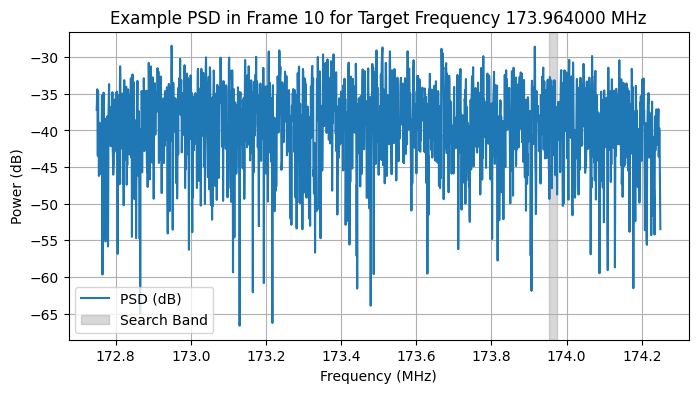

In [15]:
example_frame_idx = 10  # select a frame index to visualize
example_tf = target_freqs[0]  # visualize for the first target frequency
lower_bound = example_tf - delta_f
upper_bound = example_tf + delta_f
band_indices = np.where((freqs_abs >= lower_bound) & (freqs_abs <= upper_bound))[0]

psd_example = np.abs(stft_frames[example_frame_idx])**2

plt.figure(figsize=(8, 4))
plt.plot(freqs_abs/1e6, 10*np.log10(psd_example), label="PSD (dB)")
plt.axvspan(lower_bound/1e6, upper_bound/1e6, color="gray", alpha=0.3, label="Search Band")
# If a candidate event exists in this frame, mark it:
for event in candidate_events[example_tf]:
    if event['frame'] == example_frame_idx:
        plt.axvline(event['frequency']/1e6, color='red', linestyle='--', 
                    label=f"Detected Peak ({event['frequency']/1e6:.6f} MHz)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dB)")
plt.title(f"Example PSD in Frame {example_frame_idx} for Target Frequency {example_tf/1e6:.6f} MHz")
plt.legend()
plt.grid(True)
plt.show()